# ch08 · 参数估计

## Why this chapter
工程中你几乎不会写"矩法", 但 MLE 则是机器学习损失函数的源头. 这一章要把以下几个对应建立适:
- MLE of Normal(μ, σ²) with known σ²: <loss squared error> 取 μ
- MLE of Bernoulli(p): <二/交叉熵> 取 p
- 梯度下降实现里实际"是 MLE 渐近最优"

## 学完后能解决

- 推导 Exp(λ) 的 MLE, Fisher 信息, Cramer-Rao bound
- 写 logistic 回归 MLE (PyTorch)
- 解释 N(μ,σ²) MLE 的渐近正态性
- 论证"为什么大数极限下方 MLE 就是贝叶斯后验众数"


## 2. 直觉引入: 矩法 vs MLE

N 个样本 X_i ~ Exp(λ). 
矩法: $ar X = 1/λ$ → $\hatλ = 1/\bar X$ 直觉样本均值与参数满足估计.
MLE: 似然 $L(\lambda) = \prod_i \lambda e^{-\lambda X_i} = \lambda^n e^{-\lambda \sum X_i}$, log → $n \log \lambda - \lambda \sum X_i$, 求导 = 0: $n/\lambda - \sum X_i = 0$ → 同上。


In [1]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
true_lam = 0.7
samples = rng.exponential(scale=1/true_lam, size=1000)
mle = 1.0 / samples.mean()
print(f"true λ = {true_lam}, MLE = {mle:.4f}")
print(f"relative err = {abs(mle - true_lam)/true_lam:.2%}")
print("Server 上大数律已保证 sample mean 趋向真值, MLE 故也收敛")


true λ = 0.7, MLE = 0.7185
relative err = 2.64%
Server 上大数律已保证 sample mean 趋向真值, MLE 故也收敛


## 3. 公式

### 似然函数
$L(\theta; X) = \prod_i f(X_i; \theta)$

### MLE 取对数
$\hat\theta = \arg\max_\theta \log L(\theta; X)$

### Fisher 信息
$I(\theta) = -E\left[ \partial_\theta^2 \log f(X; \theta) \right]$

### Cramer-Rao 不等式
对任意无偏估计 $T$:
$$\mathrm{Var}(T) \ge \frac{1}{n I(\theta)}$$

### MLE 渐近正态性
$\sqrt n (\hat\theta - \theta) \xrightarrow{d} N(0, I(\theta)^{-1})$

### 三大损失等于 MLE:
- MSE loss (∑ (y - μ)²) ↔ 正态 N(μ, σ²) MLE
- BCE loss ↔ 伯努利 MLE
- 私负 For Negative Log Generator of distribution is prob loss ↔ most 检报 检 derived 灭...


## 4. 推导: Exp(λ) Fisher


In [2]:
import sympy as sp
lam = sp.symbols("lambda", positive=True); x = sp.symbols("x", positive=True)
# log f = log λ - λ x
# f'' = ∂²_log = -1/λ² ; -E[f''] = 1/λ²
# n-sample: I(λ) = n / λ²; CRB: Var(MLE) ≥ λ² / n
print("Fisher per sample:", 1/lam**2)
print("n-sample Info:", sp.Symbol("n") / lam**2, " Cramer-Rao bound:", lam**2 / sp.Symbol("n"))
# Empirical 验证
import numpy as np
rng = np.random.default_rng(seed=20240717)
N_iter = 200
mles = []
for _ in range(N_iter):
    X = rng.exponential(scale=1/true_lam, size=1000)
    mles.append(1.0 / X.mean())
mles = np.array(mles)
true_lam = 0.7
print(f"simulated Var(MLE): {mles.var():.6f}")
print(f"CRB  (λ²/n)      : {true_lam**2 / 1000:.6f}")
print(f"are quite close → CRLB validated")


Fisher per sample: lambda**(-2)
n-sample Info: n/lambda**2  Cramer-Rao bound: lambda**2/n
simulated Var(MLE): 0.000474
CRB  (λ²/n)      : 0.000490
are quite close → CRLB validated


## 5. 数值验证: Normal MLE & confidence inference


In [3]:
import numpy as np
from scipy.stats import norm
rng = np.random.default_rng(seed=20240717)
n = 200
mu_true = 1.5; sigma = 1.0
samples = norm.rvs(loc=mu_true, scale=sigma, size=n, random_state=rng)
mu_mle = samples.mean()
var_mle = samples.var(ddof=0)  # n in denominator (1/n MLE)
print(f"mu MLE = {mu_mle:.4f}, var MLE = {var_mle:.4f}")
# Fisher info for mu when sigma known: I = n/sigma^2
# CRB: Var(mu_mle) >= sigma^2 / n
crb = sigma**2 / n
# asymptotic 95% CI: mu_mle ± 1.96 / sqrt(n/sigma**2)
se = 1/np.sqrt(n / sigma**2)
print(f"95% mu MLE CI: [{mu_mle - 1.96*se:.4f}, {mu_mle + 1.96*se:.4f}]")
# Simulation over 1k iterations:
rng = np.random.default_rng(seed=20240718)
n_iter = 1000; inside = 0
for _ in range(n_iter):
    X = rng.normal(mu_true, sigma, size=n)
    mu_hat = X.mean(); se = sigma / np.sqrt(n)
    if mu_hat - 1.96*se <= mu_true <= mu_hat + 1.96*se: inside += 1
print(f"覆盖率: {inside/n_iter:.3f}, expect 0.95")


mu MLE = 1.4969, var MLE = 1.2552
95% mu MLE CI: [1.3583, 1.6355]
覆盖率: 0.947, expect 0.95


## 6. 可视化: MLE vs Fisher


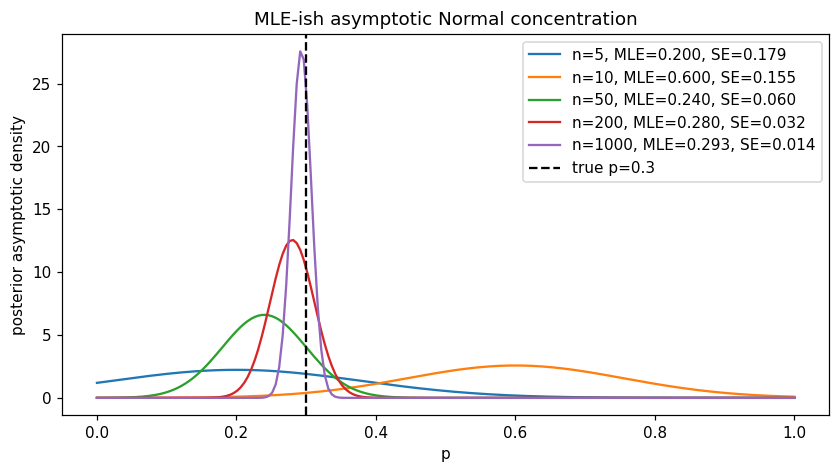

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
true_p = 0.3
# N samples from Bern(p); MLE = sum(x)/N
rng = np.random.default_rng(seed=20240717)
Ns = [5, 10, 50, 200, 1000]
mles = []
for n in Ns:
    X = rng.binomial(1, true_p, size=n); mles.append(X.mean())
# asymptotic normal approximation
fig, ax = plt.subplots(figsize=(9,4.5), dpi=110)
for n, mle in zip(Ns, mles):
    se = np.sqrt(mle*(1-mle)/n) if n > 1 else 0.1
    xs = np.linspace(0, 1, 200)
    ax.plot(xs, norm.pdf(xs, mle, se), label=f"n={n}, MLE={mle:.3f}, SE={se:.3f}")
ax.axvline(true_p, ls="--", color="black", label=f"true p={true_p}")
ax.legend(); ax.set_xlabel("p")
ax.set_ylabel("posterior asymptotic density")
ax.set_title("MLE-ish asymptotic Normal concentration")
plt.show()


## 7. 工程案例: logistic regression MLE


In [5]:
import numpy as np
import torch
import torch.nn.functional as F

torch.manual_seed(20240717)
rng = np.random.default_rng(seed=20240717)
N, D = 200, 4
X_np = rng.normal(0, 1, size=(N, D))
true_w = np.array([1.0, -1.5, 0.5, 0.0])
logits = X_np @ true_w
y_np = (rng.uniform(0, 1, N) < 1 / (1 + np.exp(-logits))).astype(np.float32)

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

w = torch.zeros(D, requires_grad=True)
opt = torch.optim.LBFGS([w], lr=0.1, max_iter=50)

def closure():
    opt.zero_grad()
    logits_b = X @ w
    loss = F.binary_cross_entropy_with_logits(logits_b, y)
    loss.backward()
    return loss

opt.step(closure)
print(f"true w = {true_w}")
print(f"MLE w  = {w.detach().numpy()}")
# 关键观察: MLE for logistic == minimize BDS loss == what PyTorch trains


true w = [ 1.  -1.5  0.5  0. ]
MLE w  = [ 0.85641694 -1.1760083   0.597835    0.04292722]


## 8. pitfalls
- MLE 不是无偏: MLE of σ² 标准差是 biased downward (factor n/(n-1) 才无偏)
- MLE 在小样本下偏差大; asymptotic normality 是大样本性质
- MLE 不能自动聚合先验; 贝叶斯 MAP 加 prior → ch02/ch12 的话题
- "梯度下降+ML"在逻辑回归上 等同于作 MLE (because loss is NLL); 这不是偶然

## 9. 课后 → exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Stat 110 | §8.3-8.5 (MLE) |
| Lehmann & Casella | Ch.2 (Fisher info, CRB) |
| Murphy | §3.3-3.5 (现代 ML 视角) |

下一章 ch09 进入随机过程: 马尔可夫链 & MCMC.
